In [2]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.5 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import motifs, SeqIO
from Bio.Seq import Seq
from collections import Counter
import random

In [4]:
sites = [
    "GAGGTAAAC",
    "TCCGTAAGC",
    "CAGGTTGGA",
    "ACAGTCAGC",
    "TAGGTCAGC",
    "CAGGTCAGC",
    "CAGGTCGAT",
    "CAGGTCAGC",
    "CAGGTCAGC",
    "CAGGTTGGC"
]

Функции вычисления pwm из задания 1_1:

In [5]:
def get_pfm(sites_list, nuc_order, seq_length):
    pfm = np.zeros((len(nuc_order), seq_length), dtype=int)
    for i, nuc in enumerate(nuc_order):
        for pos in range(seq_length):
            count = sum(1 for seq in sites_list if seq[pos] == nuc)
            pfm[i, pos] = count
    return pfm

def pfm_to_ppm(pfm_matrix, pseudocount=0.1):
    pfm_pseudo = pfm_matrix + pseudocount
    column_sums = pfm_pseudo.sum(axis=0)
    ppm = pfm_pseudo / column_sums
    return ppm

def ppm_to_pwm(ppm_matrix, bg_dict, nuc_order):
    bg_vector = np.array([bg_dict[nuc] for nuc in nuc_order]).reshape(-1, 1)
    pwm = np.log2(ppm_matrix / bg_vector)
    return pwm


In [6]:
sites = [site.strip() for site in sites]
seq_length = len(sites[0])
nuc_order = ['A', 'C', 'G', 'T']

print("Мотив создан:")
print(f"Длина мотива: {seq_length}")
print(f"Количество последовательностей: {len(sites)}")

Мотив создан:
Длина мотива: 9
Количество последовательностей: 10


Вычисление PFM и фон:

In [7]:
pfm = get_pfm(sites, nuc_order, seq_length)
print("\nPFM матрица:")
for i, nuc in enumerate(nuc_order):
    print(f"{nuc}: {pfm[i]}")
bg_dict = {
    'A': 0.295,
    'C': 0.205,
    'G': 0.205,
    'T': 0.295
}


PFM матрица:
A: [1 8 1 0 0 2 7 2 1]
C: [6 2 1 0 0 6 0 0 8]
G: [ 1  0  8 10  0  0  3  8  0]
T: [ 2  0  0  0 10  2  0  0  1]


In [8]:
ppm = pfm_to_ppm(pfm, pseudocount=0.1)
pwm = ppm_to_pwm(ppm, bg_dict, nuc_order)

print("\nPPM матрица (с псевдосчётом 0.1):")
for i, nuc in enumerate(nuc_order):
    print(f"{nuc}: {[round(val, 3) for val in ppm[i]]}")

print("\nPWM матрица (log2(частота/фон)):")
for i, nuc in enumerate(nuc_order):
    print(f"{nuc}: {[round(val, 3) for val in pwm[i]]}")


PPM матрица (с псевдосчётом 0.1):
A: [np.float64(0.106), np.float64(0.779), np.float64(0.106), np.float64(0.01), np.float64(0.01), np.float64(0.202), np.float64(0.683), np.float64(0.202), np.float64(0.106)]
C: [np.float64(0.587), np.float64(0.202), np.float64(0.106), np.float64(0.01), np.float64(0.01), np.float64(0.587), np.float64(0.01), np.float64(0.01), np.float64(0.779)]
G: [np.float64(0.106), np.float64(0.01), np.float64(0.779), np.float64(0.971), np.float64(0.01), np.float64(0.01), np.float64(0.298), np.float64(0.779), np.float64(0.01)]
T: [np.float64(0.202), np.float64(0.01), np.float64(0.01), np.float64(0.01), np.float64(0.971), np.float64(0.202), np.float64(0.01), np.float64(0.01), np.float64(0.106)]

PWM матрица (log2(частота/фон)):
A: [np.float64(-1.48), np.float64(1.401), np.float64(-1.48), np.float64(-4.939), np.float64(-4.939), np.float64(-0.547), np.float64(1.211), np.float64(-0.547), np.float64(-1.48)]
C: [np.float64(1.517), np.float64(-0.022), np.float64(-0.955), np.f

Генератор случайных последовательностей:

In [9]:
def generate_random_sequence(length, freqs):
    """Генерирует случайную последовательность заданной длины с заданными частотами"""
    nucleotides = ['A', 'C', 'G', 'T']
    probabilities = [freqs['A'], freqs['C'], freqs['G'], freqs['T']]
    return ''.join(random.choices(nucleotides, weights=probabilities, k=length))

def calculate_pwm_score(sequence, pwm, nuc_order):
    """Рассчитывает скор последовательности по PWM матрице"""
    score = 0
    nuc_to_index = {nuc: i for i, nuc in enumerate(nuc_order)}

    for pos, nucleotide in enumerate(sequence):
        if pos < pwm.shape[1]:  # Проверка длины
            nuc_idx = nuc_to_index[nucleotide]
            score += pwm[nuc_idx, pos]
    return score

Генерация 100,000 фоновых последовательностей и расчет скоров:

In [12]:
n_sequences = 100000
background_scores = []

for i in range(n_sequences):
    seq = generate_random_sequence(seq_length, bg_dict)
    score = calculate_pwm_score(seq, pwm, nuc_order)
    background_scores.append(score)

background_scores = np.array(background_scores)

Построение гистограмм:

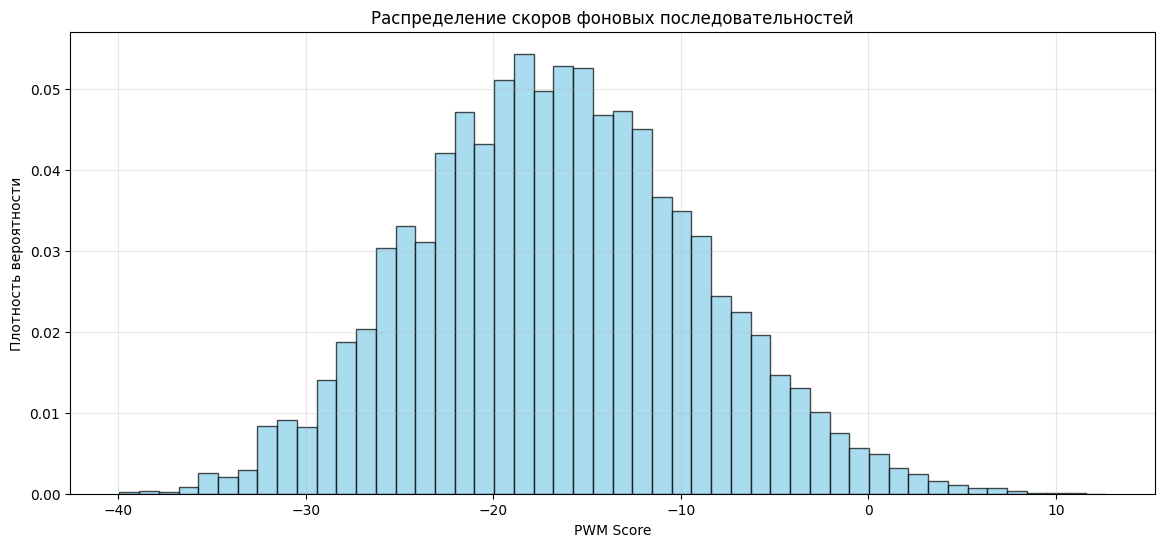

In [14]:
plt.figure(figsize=(14, 6))

n, bins, patches = plt.hist(background_scores, bins=50, density=True,
                            alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('PWM Score')
plt.ylabel('Плотность вероятности')
plt.title('Распределение скоров фоновых последовательностей')
plt.grid(True, alpha=0.3)
plt.show()

Функция get_pvalue, которая Возвращает долю фоновых скоров ≥ заданного score

In [15]:
def get_pvalue(score, background_scores):
    """Возвращает долю фоновых скоров ≥ заданного score"""
    return np.sum(background_scores >= score) / len(background_scores)

In [16]:
target_pvalue = 1e-4

sorted_scores = np.sort(background_scores)[::-1]

index = int(target_pvalue * n_sequences)
if index < len(sorted_scores):
    threshold = sorted_scores[index]
    actual_pvalue = get_pvalue(threshold, background_scores)
else:
    threshold = sorted_scores[-1]
    actual_pvalue = get_pvalue(threshold, background_scores)

In [17]:
print(f"Целевой p-value: {target_pvalue:.1e}")
print(f"Рассчитанный порог (threshold): {threshold:.3f}")
print(f"Фактический p-value для этого порога: {actual_pvalue:.1e}")
print(f"Количество последовательностей с скором ≥ {threshold:.3f}: "
      f"{np.sum(background_scores >= threshold)} из {n_sequences}")

Целевой p-value: 1.0e-04
Рассчитанный порог (threshold): 10.178
Фактический p-value для этого порога: 1.1e-04
Количество последовательностей с скором ≥ 10.178: 11 из 100000
